In [ ]:
## 1. Import Libraries
#Import seluruh pustaka penting yang digunakan dalam analisis, visualisasi, dan pemodelan.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
## 2. Load Dataset
#Memuat dataset dan melihat struktur awal.

# Enclose the filename in quotes to treat it as a string literal
df = pd.read_csv('Food_Delivery_Times (1).csv')
print(df.info())
print(df.describe())
print("Duplikat:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB
None
          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count  1000.000000  1000.000000           1000.000000              970.000000   
mean    500.500000    10.059970             16.982000                4.579381   
s

In [ ]:
## 3. Problem Statement & Objective
### Problem Statement
#Bagaimana cara memprediksi waktu pengiriman makanan (Delivery_Time_min) dengan akurasi tinggi? Apa saja faktor utama yang memengaruhi waktu pengiriman?

### Tujuan Proyek
# Mengembangkan model prediktif untuk estimasi waktu pengiriman makanan.
# Mengidentifikasi fitur yang paling berpengaruh terhadap waktu pengiriman.
# Memberikan insight untuk pengambilan keputusan logistik.


In [ ]:
## 4. Data Preprocessing
### Langkah-langkah:
#Menghapus kolom ID yang tidak relevan
#Menangani nilai kosong dan duplikat
#Encoding variabel kategorikal
#Normalisasi fitur numerik

df_cleaned = df.drop(columns=["Order_ID"]).dropna().drop_duplicates()
df_encoded = pd.get_dummies(df_cleaned, columns=["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"], drop_first=True)

scaler = StandardScaler()
numerical_cols = ["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs"]
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])


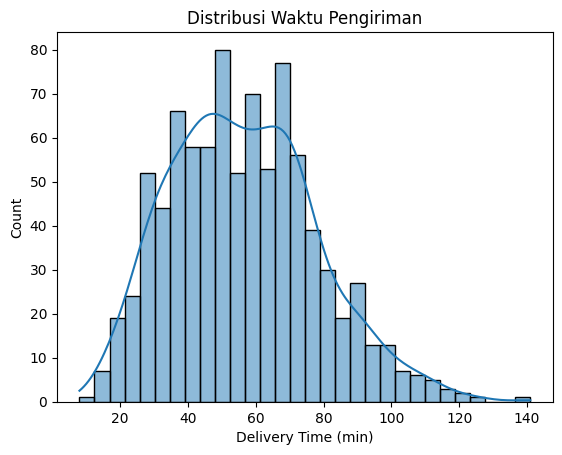

In [ ]:
## 5. Exploratory Data Analysis (EDA)
### Distribusi Waktu Pengiriman
sns.histplot(df_cleaned['Delivery_Time_min'], bins=30, kde=True)
plt.title('Distribusi Waktu Pengiriman')
plt.xlabel('Delivery Time (min)')
plt.show()



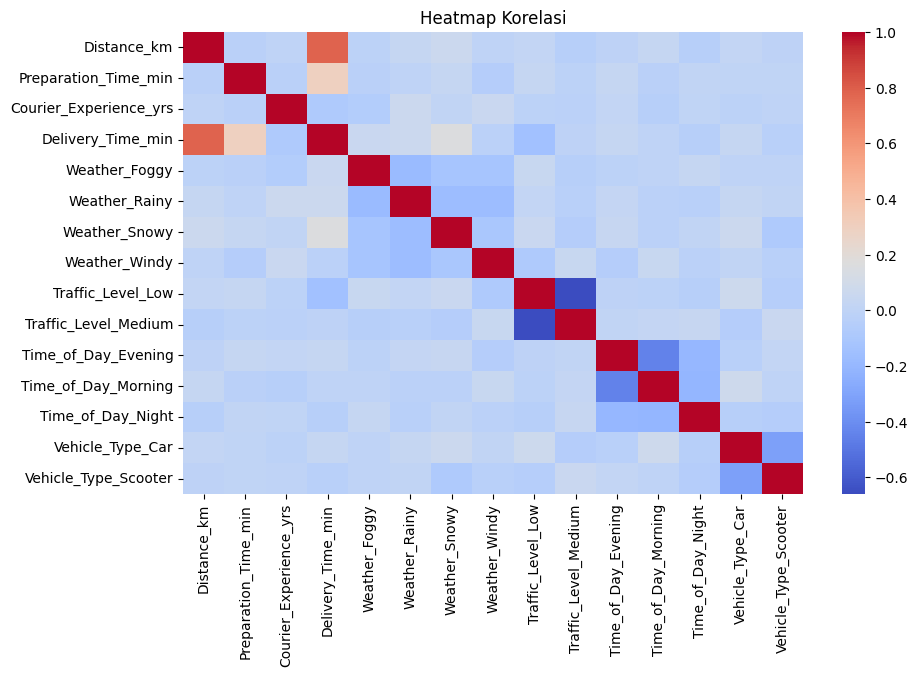

In [ ]:
### Korelasi Fitur
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()



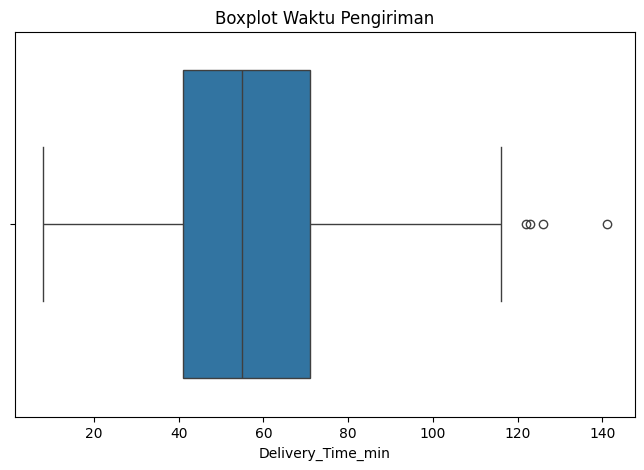

In [ ]:
### Outlier Detection
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_cleaned['Delivery_Time_min'])
plt.title("Boxplot Waktu Pengiriman")
plt.show()



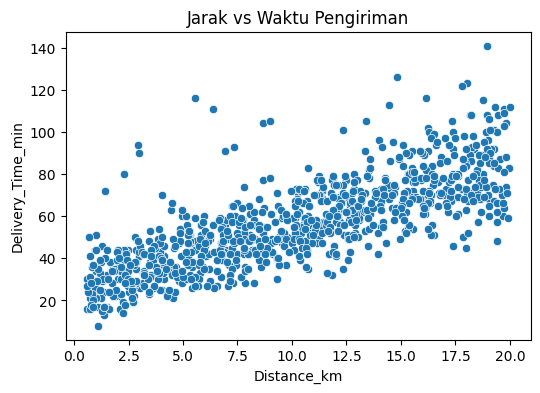

In [ ]:

### Hubungan Jarak dan Waktu Pengiriman
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df_cleaned['Distance_km'], y=df_cleaned['Delivery_Time_min'])
plt.title("Jarak vs Waktu Pengiriman")
plt.show()

In [ ]:
## 6. Train-Test Split
X = df_encoded.drop("Delivery_Time_min", axis=1)
y = df_encoded["Delivery_Time_min"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
## 7. Modeling
### Model yang Digunakan:
#Linear Regression: baseline yang cepat dan mudah diinterpretasi
#Random Forest: kuat terhadap data non-linear dan outlier
#Gradient Boosting: meningkatkan akurasi dengan teknik boosting
#XGBoost: efisien dan powerful untuk prediksi

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("\nModel Performance:")
print(results_df)


Model Performance:
               Model       MAE       RMSE        R2
0  Linear Regression  5.319617   8.273317  0.832531
2  Gradient Boosting  6.562193   9.289371  0.788872
1      Random Forest  6.991412   9.943924  0.758070
3            XGBoost  7.387050  10.878373  0.710464


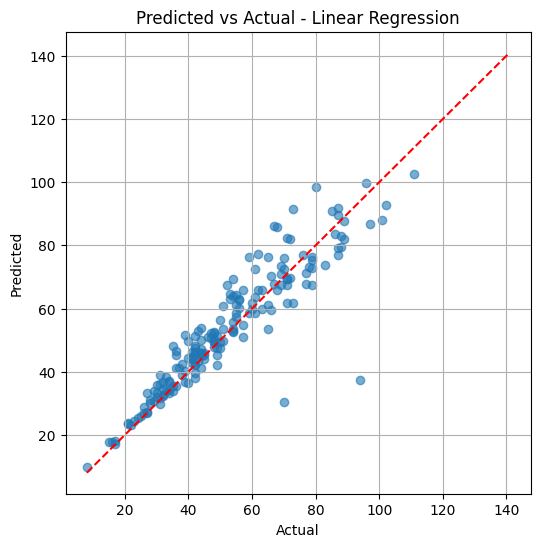

In [ ]:
### Visualisasi Prediksi vs Aktual (Model Terbaik)
best_model_name = results_df.iloc[0]['Model']
best_pred = trained_models[best_model_name].predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.grid()
plt.show()

In [ ]:
## 8. Hyperparameter Tuning (Random Forest)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_score = grid_search.best_score_
print("\nBest Random Forest R2 (CV):", best_score)
print("Best Params:", grid_search.best_params_)


Best Random Forest R2 (CV): 0.6996662463676075
Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
## 9. Cross-Validation Score
cross_val = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
print("\nCross-validation R2 scores:", cross_val)
print("Mean CV R2:", cross_val.mean())




Cross-validation R2 scores: [0.71207035 0.7083264  0.68701412 0.64396989 0.74695047]
Mean CV R2: 0.6996662463676075


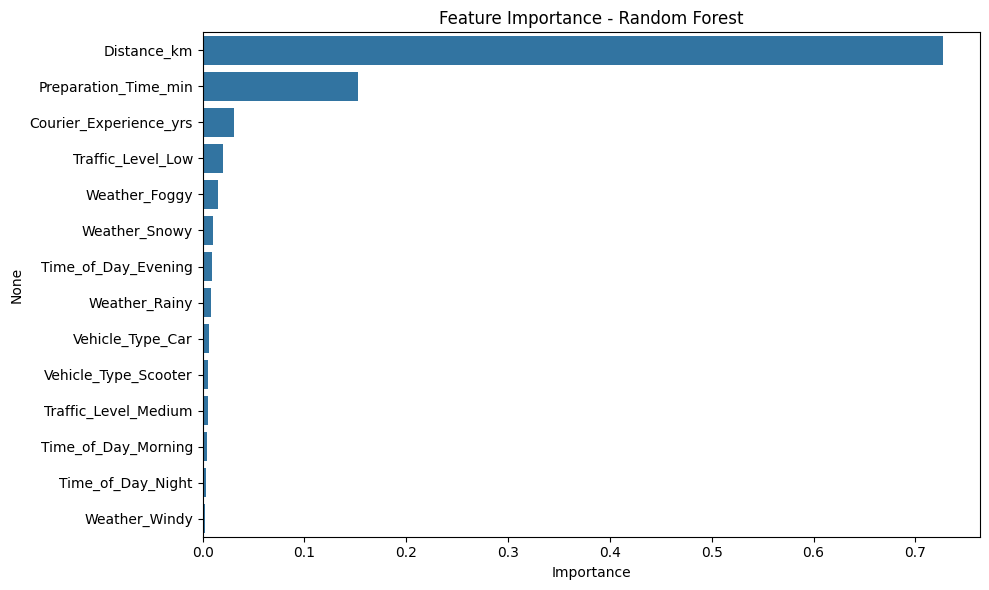

In [ ]:
## 10. Feature Importance
rf_model = best_model
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 11. Insight dan Rekomendasi
📌 Fitur paling penting dalam memprediksi waktu pengiriman: Distance, Preparation Time, dan Traffic Level.
📌 Random Forest dan XGBoost menunjukkan performa terbaik dengan R² tinggi, cocok untuk data kompleks.
📌 Model ini dapat digunakan oleh tim logistik untuk prediksi waktu pengiriman dan optimalisasi rute.
📌 Insight dari model bisa membantu pengambilan keputusan operasional dan peningkatan SLA.
